In [ ]:
import gdown

# Replace FILE_ID with your actual file ID
file_id = "1kOqxcPhlBLy5I0WEHzOWZC6HXryOehlZ"
output_file = "Apple_Datasets.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1kOqxcPhlBLy5I0WEHzOWZC6HXryOehlZ
From (redirected): https://drive.google.com/uc?id=1kOqxcPhlBLy5I0WEHzOWZC6HXryOehlZ&confirm=t&uuid=4090a16e-0ba8-4b52-a913-aa85f1f7eb51
To: /content/Apple_Datasets.zip
100%|██████████| 165M/165M [00:01<00:00, 138MB/s]


'Apple_Datasets.zip'

In [ ]:
import zipfile
z = zipfile.ZipFile('/content/Apple_Datasets.zip')
z.extractall()

In [ ]:
!pip install ultralytics

In [ ]:
import cv2
from ultralytics import YOLO

In [ ]:
model = YOLO('yolo11x.pt')

model.train(
    data = 'Apple_Datasets/data.yaml',
    batch = 8,
    epochs = 50,
    imgsz = 640,
    name = "apple_datasets_yolov11",
    save = True,
    patience = 20,
    save_period = -1,
    val = True
)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Apple_Datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=apple_datasets_yolov115, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ed710189ac0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


0: 384x640 35 apples, 11.8ms
Speed: 4.8ms preprocess, 11.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 47 apples, 8.7ms
Speed: 2.4ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 41 apples, 9.5ms
Speed: 2.9ms preprocess, 9.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 57 apples, 9.2ms
Speed: 2.2ms preprocess, 9.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 45 apples, 9.1ms
Speed: 2.2ms preprocess, 9.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 50 apples, 14.2ms
Speed: 2.2ms preprocess, 14.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 48 apples, 8.7ms
Speed: 2.1ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 55 apples, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 6

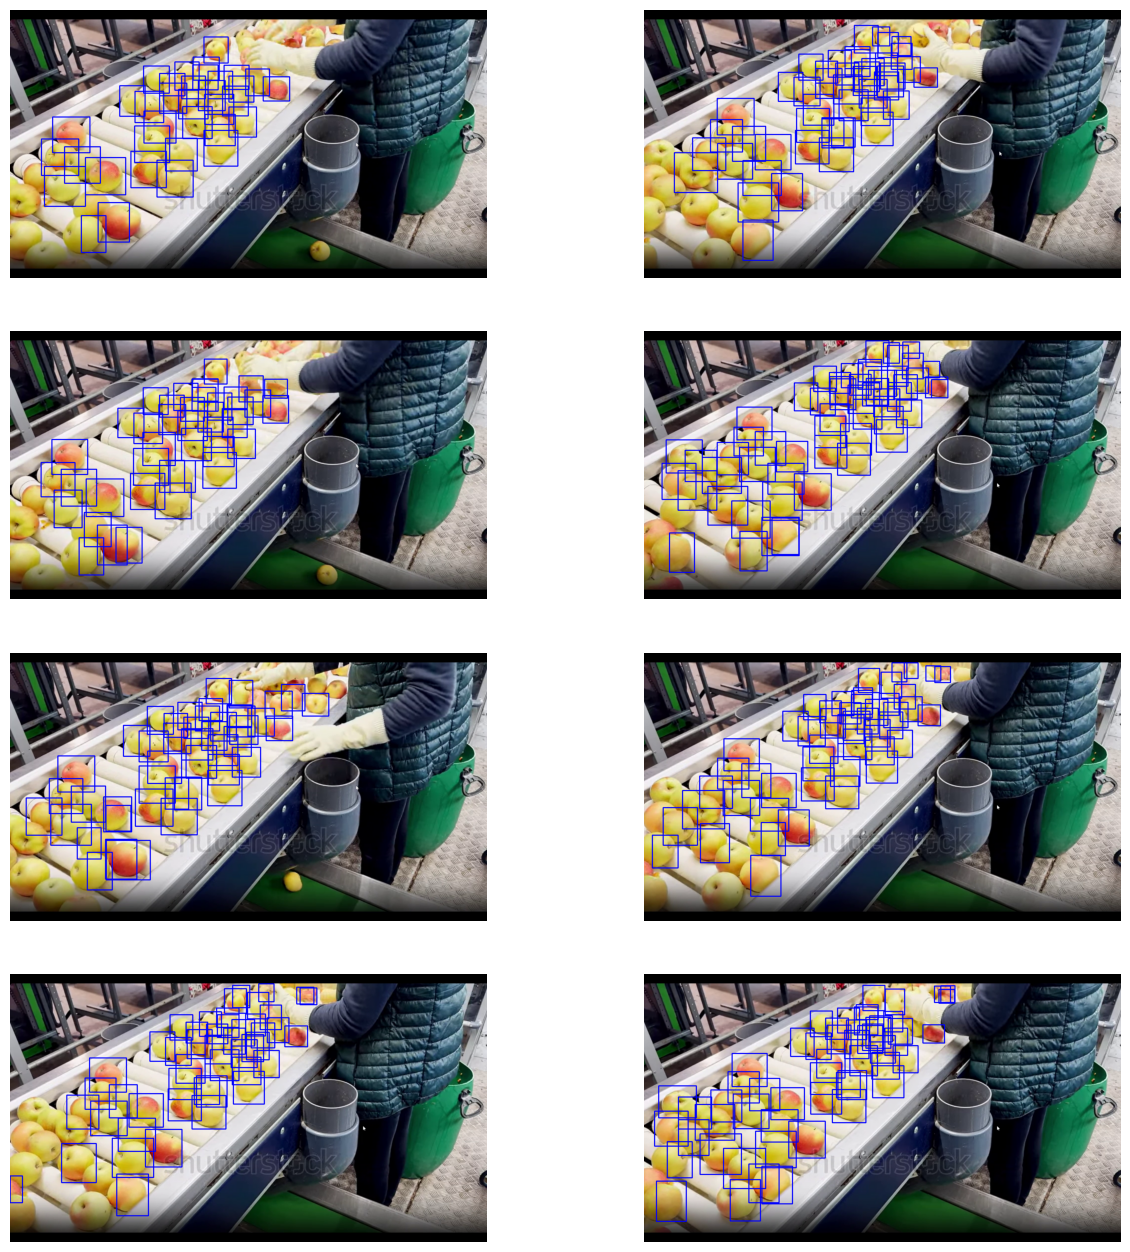

In [ ]:
import matplotlib.pyplot as plt
import os
import random


model = YOLO("runs/detect/apple_datasets_yolov115/weights/best.pt")

images_path = "Apple_Datasets/test"

fig, ax = plt.subplots(4,2,figsize=(15,16))
ax = ax.ravel()

for i in range(8):
    img_files = os.listdir(images_path)
    img_file_name = random.choice(img_files)

    img_path = os.path.join(images_path,img_file_name)

    img = cv2.imread(img_path)
    results = model(img)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    ax[i].imshow(img)
    ax[i].axis("off")

plt.show()
